# MPRAGE, and the one number the whole sequence exists to control

An inversion, a wait, a train of gradient echoes, a recovery — repeated once per shot. Almost
everything here already exists: [`gre_2d/`](../gre_2d/01_build.ipynb) built the train, and
`sc.modules.IRPrep` is the one new module. What this notebook is about is the **arithmetic
between them**, which no compiler can check.

TI is the inversion's *effective centre* to the acquisition of **k = 0**. Both ends of that
measurement are semantic offsets a tree of events cannot know, so both are module methods:

| | |
|---|---|
| `IRPrep.time_to_center()` | block start → the inversion's effective centre. 5.1 ms for a 10 ms hyperbolic secant, and a TI referenced to the block start instead is wrong by exactly that. |
| `GRE2D.time_to_center_line(lines=…, dummies=…)` | block start → the readout of `center_line`. Depends on the **ordering**, so it takes the same arguments `build` does. |

**This notebook does not import an `MPRAGE2D`,** because there is not one to import: it has a
single consumer — this notebook — and a module with one consumer belongs where that consumer is.
It is written here, as an `sc.Module` subclass, after the loop it is extracted from.

Everything here is arithmetic. [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb)
takes the `.seq` files this writes and asks whether the magnetisation actually does what the
timeline says.

**Output:** two `.seq` files in `seq/` — the same lines under two orderings — and the nominal
k-space beside them.

## 0. The scanner, and the protocol

**`TURBO = 32` and four shots.** The turbo factor is how many lines one inversion pays for, and
it is the parameter that trades contrast against time: every line in a shot is acquired at a
different point on the same recovery curve, so a long train blurs the T1 weighting the inversion
created. Four shots at a 2.5 s interval is a 10 s scan for 128 lines.

**`FLIP_DEG = 8.0`.** MPRAGE trains run at low flip angles for the same reason: each excitation
spends some of the longitudinal magnetisation the inversion prepared, so a train at 15° has
destroyed most of its own contrast by the time it reaches the end.

**`INVERSION_PULSE = 'block'`, and this one is a compromise worth reading.** `IRPrep` defaults to
an adiabatic `'hypsec'`, which is the right choice on a scanner: B1 insensitivity is the entire
reason to use a sophisticated inversion pulse. But §1 of `02` measures what the simulator this
example is checked against actually does with one, and the answer is that it applies **an
instantaneous rotation by the pulse's integrated flip angle** — 289° for a hyperbolic secant,
which does not invert. A hard 180° block pulse integrates to exactly 180° and does. So the
example is built with the pulse the *simulation* can be trusted about, and §1 below shows what
changing it back costs in the timeline: 4.5 ms, absorbed entirely by `time_to_center`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)      # (x, y)  -- readout, phase
MATRIX = (128, 128)          # (nx, ny)
THICKNESS_MM = 5.0
FLIP_DEG = 8.0
BANDWIDTH_HZ_PX = 400.0
SPOIL_CYCLES = 4.0

TI_S = 0.80                  # inversion centre -> acquisition of k = 0
SHOT_INTERVAL_S = 2.5        # inversion to inversion
TURBO = 32                   # lines per shot
DUMMY_SHOTS = 5              # whole shots, not TRs -- and five is measured, not guessed

INVERSION_PULSE = 'block'
INVERSION_DURATION_S = 1e-3
INVERSION_SPOIL_CYCLES = 8.0

NX, NY = MATRIX
CENTER_LINE = NY // 2
N_SHOTS = NY // TURBO

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

print(f'{NX} x {NY} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'{N_SHOTS} shots of {TURBO} lines, {SHOT_INTERVAL_S:.1f} s apart '
      f'-> {N_SHOTS * SHOT_INTERVAL_S:.1f} s of acquisition '
      f'(+{DUMMY_SHOTS * SHOT_INTERVAL_S:.1f} s of dummy shots)')
print(f'TI {TI_S * 1e3:.0f} ms; white matter nulls at T1*ln2 = {0.9 * np.log(2) * 1e3:.0f} ms '
      f'for T1 = 900 ms')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128 over 220 x 220 mm, 5 mm slice
4 shots of 32 lines, 2.5 s apart -> 10.0 s of acquisition (+12.5 s of dummy shots)
TI 800 ms; white matter nulls at T1*ln2 = 624 ms for T1 = 900 ms


---
# 1. The two modules, and the two numbers

`IRPrep` is an inversion pulse and the **crusher after it**, held in fixed relationship. The
argument for bundling them: an inversion is never perfect, and the transverse magnetisation B1
inhomogeneity leaves behind has a whole TI of recovery to rephase in before the first readout,
where it would appear as a stripe *that changes with TI* — which reads as a contrast problem
rather than as a spoiling one. `spoil_cycles_per_voxel` defaults to `8.0` rather than the readout
spoiler's `4.0` for that reason. §5 of `02` tries to measure it and finds that this *simulator*
cannot show it, which is worth reading before believing the paragraph above.

`GRE2D` is reused **per shot, not per scan**: `gre(lines=segment)` is one turbo train, and it is
the same call that produced a whole scan in `gre_2d/`. One instance, one design, one cheap call
per shot.

In [2]:
inv = sc.modules.IRPrep(
    opts=opts, thickness_mm=None,               # non-selective: the usual MPRAGE choice
    pulse=INVERSION_PULSE, duration_s=INVERSION_DURATION_S,
    spoil_cycles_per_voxel=INVERSION_SPOIL_CYCLES, spoil_voxel_mm=THICKNESS_MM,
)
gre = sc.modules.GRE2D(
    opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
    flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX,
    spoil_cycles_per_voxel=SPOIL_CYCLES,
)

prep_s = inv().duration

print(f'inversion block   {prep_s * 1e3:8.3f} ms   (pulse, then the crusher)')
print(f'  time_to_center  {inv.time_to_center() * 1e3:8.3f} ms   <- TI is measured from here')
print(f'  the tail after  {(prep_s - inv.time_to_center()) * 1e3:8.3f} ms   '
      f'<- and nothing may overlap this')
print()
print(f'train TE          {gre.tr.te_s * 1e3:8.3f} ms')
print(f'train TR          {gre.tr.tr_s * 1e3:8.3f} ms   '
      f'-> a {TURBO}-line train is {TURBO * gre.tr.tr_s * 1e3:.1f} ms long')
print(f'centre line       {gre.center_line:8d}')

inversion block      2.340 ms   (pulse, then the crusher)
  time_to_center     0.600 ms   <- TI is measured from here
  the tail after     1.740 ms   <- and nothing may overlap this

train TE             3.368 ms
train TR             7.890 ms   -> a 32-line train is 252.5 ms long
centre line             64


### The centre is not half the block, and it is not the block start

The crusher sits *after* the pulse, so "halfway through the inversion block" is wrong — and it is
wrong by a different amount for every pulse shape. Swapping the hard pulse for the module's
adiabatic default moves the centre by 4.5 ms, and that is 4.5 ms of TI error for anybody who
referenced the block start instead.

In [3]:
adiabatic = sc.modules.IRPrep(opts=opts, thickness_mm=None, spoil_voxel_mm=THICKNESS_MM,
                              spoil_cycles_per_voxel=INVERSION_SPOIL_CYCLES)

print(f'{"pulse":10s} {"block / ms":>12s} {"centre / ms":>13s} {"half block / ms":>17s}')
for name, module in (('block', inv), ('hypsec', adiabatic)):
    block = module()
    print(f'{name:10s} {block.duration * 1e3:12.3f} {module.time_to_center() * 1e3:13.3f} '
          f'{block.duration / 2 * 1e3:17.3f}')
print()
print(f'the two centres differ by '
      f'{(adiabatic.time_to_center() - inv.time_to_center()) * 1e3:.3f} ms, which is what the '
      f'train placement below has to absorb')

pulse        block / ms   centre / ms   half block / ms
block             2.340         0.600             1.170
hypsec           11.340         5.101             5.670

the two centres differ by 4.500 ms, which is what the train placement below has to absorb


### `time_to_center_line` depends on the ordering, which is why it is a method

k = 0 is acquired *somewhere inside* the train, and where depends on the list of lines. Centric
ordering puts it first; linear puts it in the middle. The same TI therefore places those two
trains most of a train-length apart, and a sequence that used one constant for both would be
wrong for whichever one it was not written against.

In [4]:
segment_linear = tuple(range(CENTER_LINE - TURBO // 2, CENTER_LINE + TURBO // 2))
segment_centric = tuple(sorted(segment_linear, key=lambda line: (abs(line - CENTER_LINE), line)))

for name, segment in (('linear', segment_linear), ('centric', segment_centric)):
    print(f'{name:8s} {segment[:8]} ... ({len(segment)} lines)')
    print(f'         k = 0 at position {segment.index(CENTER_LINE):2d}, '
          f'{gre.time_to_center_line(lines=segment) * 1e3:8.3f} ms into the block')
print()
# The dummies term is the one that gets dropped, and it is silent: the block starts at the first
# dummy, not at the first acquired line.  Twenty dummies at this TR is 139 ms of TI error.
with_dummies = gre.time_to_center_line(lines=segment_linear, dummies=20)
print(f'and dummies=20 moves it by {(with_dummies - gre.time_to_center_line(lines=segment_linear)) * 1e3:.3f} ms '
      f'= 20 x TR, which is why the query takes the same arguments build does')

linear   (48, 49, 50, 51, 52, 53, 54, 55) ... (32 lines)
         k = 0 at position 16,  131.208 ms into the block
centric  (64, 63, 65, 62, 66, 61, 67, 60) ... (32 lines)
         k = 0 at position  0,    4.968 ms into the block

and dummies=20 moves it by 157.800 ms = 20 x TR, which is why the query takes the same arguments build does


---
# 2. One shot, written out

Two blocks are placed per shot, and the arithmetic reads better as a timeline than as a formula.
`t_shot` is where the **`IRPrep` block** goes — *not* where the inversion happens, which is
`time_to_center()` later:

```text
t_shot                                                          t_shot + shot_interval_s
  │                                                                             │
  ├── IRPrep block ──┤                                                          │
  │        ●         │                                                          │
  │   inversion centre                                                          │
  ├────────┤ inv.time_to_center()                                               │
  │        │                                                                    │
  │        ├───────────────── ti_s ─────────────────►● k = 0 acquired           │
  │                                                  │                          │
  │                  t_train ├───────────────────────┤ gre.time_to_center_line  │
  │                          ├─────── GRE block ──────────────┤                 │
```

Three terms, and each one is a module answering a question about itself:

In [5]:
def train_offset_s(segment):
    """Seconds from the start of a shot to the start of its GRE train."""
    return float(grad_raster.ceil(
        inv.time_to_center()                            # to the inversion's centre
        + TI_S                                          # forward by TI, to where k = 0 belongs
        - gre.time_to_center_line(lines=segment)        # back to where the train must start
    ))


def shot(segment, t_shot=0.0, *, acquire=True):
    """One shot: inversion, wait, train.  The recovery is the gap to the next `t_shot`."""
    out = sc.LogicBlock('shot')
    if acquire:
        # TRID marks the repeating unit for a scanner's loop detection.  It attaches to the first
        # readout at or after its own time, so a shot that acquires nothing cannot carry one --
        # and a TRID left dangling would bind to the *next* shot's first readout instead.
        out.add(t_shot, pp.make_label(type='SET', label='TRID', value=1))
    out.add(t_shot, inv())
    out.add(t_shot + train_offset_s(segment), train(segment, acquire=acquire))
    return out


def train(segment, *, acquire=True):
    """The turbo train.  `dummies=0` always: MPRAGE's steady state is shot-to-shot."""
    if acquire:
        return gre(lines=segment, dummies=0)
    # A dummy shot plays the same gradients and samples nothing.  GRE2D has no `acquire`, because
    # a scan that acquires nothing is not a scan -- so the loop is written out here, which is
    # eight lines and says exactly what a dummy shot is.
    out = sc.LogicBlock('GRE2D')
    for n, line in enumerate(segment):
        out.add(n * gre.tr.tr_s,
                gre.tr(line=line, phase_deg=gre.phase_deg(n), acquire=False))
    return out


one = shot(segment_centric)

# The whole shot is 16 repetitions deep, so only the head of the tree is printed: the inversion,
# the gap, and the first repetition of the train.  What is worth seeing is the two top-level
# children and the offset between them.
print('\n'.join(one.describe().splitlines()[:16]))
print(f'    ... {TURBO - 1} more repetitions')
print()
print(f'the GRE block starts {train_offset_s(segment_centric) * 1e3:.2f} ms into the shot, '
      f'which is {TI_S * 1e3:.0f} ms of TI')
print(f'minus {gre.time_to_center_line(lines=segment_centric) * 1e3:.2f} ms of train, '
      f'plus {inv.time_to_center() * 1e3:.2f} ms to the inversion centre')

shot  1048.12 ms
  +0.0 us  labelset
  +0.0 us  IRPrep  2.34 ms
    +0.0 us  rf
    +1130.0 us  spoiler  1.21 ms
      +0.0 us  trap z
  +795640.0 us  GRE2D  252.48 ms
    +0.0 us  GRE2DTR  7.89 ms
      +0.0 us  Excitation  3.67 ms
        +0.0 us  rf
        +0.0 us  trap z
        +3150.0 us  trap z
      +3150.0 us  PhaseEncode  0.52 ms
        +0.0 us  trap y
      +3150.0 us  CartesianLine  3.10 ms
        +0.0 us  trap x
    ... 31 more repetitions

the GRE block starts 795.64 ms into the shot, which is 800 ms of TI
minus 4.97 ms of train, plus 0.60 ms to the inversion centre


### The timing diagram

Every later bug in this notebook is a mis-drawn arrow on this picture. Note where `t_shot` is:
the *block* starts there, and the inversion itself is `time_to_center()` later.

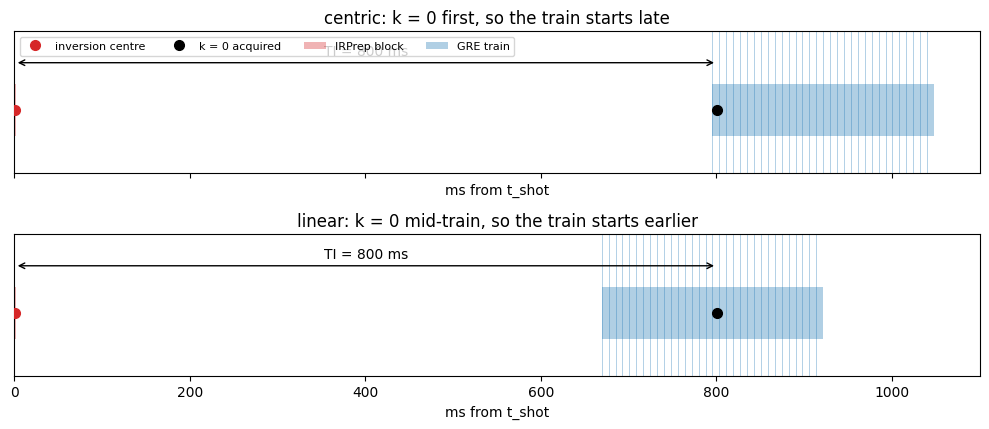

In [6]:
def timing_figure(segment, ax, title):
    """Mark t_shot, the inversion centre, TI, the train start and k = 0."""
    offset = train_offset_s(segment)
    t_centre = inv.time_to_center()
    t_k0 = offset + gre.time_to_center_line(lines=segment)
    train_s = len(segment) * gre.tr.tr_s

    ax.barh(1, prep_s * 1e3, left=0, height=0.5, color='C3', alpha=0.35, label='IRPrep block')
    ax.barh(1, train_s * 1e3, left=offset * 1e3, height=0.5, color='C0', alpha=0.35,
            label='GRE train')
    for n in range(len(segment)):
        ax.axvline((offset + n * gre.tr.tr_s) * 1e3, color='C0', lw=0.4, alpha=0.6)
    ax.plot([t_centre * 1e3], [1], 'o', color='C3', ms=7, zorder=5, label='inversion centre')
    ax.plot([t_k0 * 1e3], [1], 'o', color='k', ms=7, zorder=5, label='k = 0 acquired')
    ax.annotate('', xy=(t_k0 * 1e3, 1.45), xytext=(t_centre * 1e3, 1.45),
                arrowprops={'arrowstyle': '<->', 'color': 'k'})
    ax.text(0.5 * (t_centre + t_k0) * 1e3, 1.52, f'TI = {TI_S * 1e3:.0f} ms', ha='center')
    ax.set(title=title, xlabel='ms from t_shot', yticks=[], ylim=(0.4, 1.75))


fig, axes = plt.subplots(2, 1, figsize=(10, 4.4), sharex=True)
timing_figure(segment_centric, axes[0], 'centric: k = 0 first, so the train starts late')
timing_figure(segment_linear, axes[1], 'linear: k = 0 mid-train, so the train starts earlier')
axes[0].legend(loc='upper left', fontsize=8, ncol=4)
fig.tight_layout()

### The check that matters

`sc.kspace` walks the compiled trajectory, so it reports where the readouts *actually* land. The
echo of `center_line` must sit exactly `TI_S` after the inversion's effective centre — for
**both** orderings. A placement that ignored `time_to_center_line` would pass for one and fail
for the other, which is why both are asserted.

In [7]:
def measured_ti_s(tree, segment):
    """TI, read off the compiled trajectory: inversion centre to the echo of `center_line`."""
    k = sc.kspace(tree, opts)
    t_echo = k['t_adc'].reshape(len(segment), NX)[segment.index(CENTER_LINE), NX // 2]
    return float(t_echo) - inv.time_to_center()


for name, segment in (('centric', segment_centric), ('linear', segment_linear)):
    measured = measured_ti_s(shot(segment), segment)
    assert abs(measured - TI_S) < 1e-5, f'{name}: TI is {measured * 1e3:.3f} ms'
    print(f'{name:8s} measured TI {measured * 1e3:9.4f} ms   (asked {TI_S * 1e3:.4f} ms)')

E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 128 blocks over the vector-norm limit (legal on real amplifiers): shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 798.790 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 798.790 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (grad 141% at 801.890 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (slew 139% at 801.890 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 806.680 ms) (+123 more sites)
  seq = compile_sequence(tree, opts)


centric  measured TI  800.0077 ms   (asked 800.0000 ms)


linear   measured TI  800.0077 ms   (asked 800.0000 ms)


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 128 blocks over the vector-norm limit (legal on real amplifiers): shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 672.550 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (slew 137% at 672.550 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (grad 142% at 675.650 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (slew 141% at 675.650 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 680.440 ms) (+123 more sites)
  seq = compile_sequence(tree, opts)


---
# 3. The floor, and the overlap it prevents

Nothing in the timeline forces `t_train` to fall after the `IRPrep` block **ends**, and
`LogicBlock` overlaps silently. A TI that is too short therefore does not fail — it lays the
first excitation's slice gradient on top of the inversion crusher, the compiler sums them on `z`,
and what comes out is *wrong* rather than *rejected*.

$$\mathrm{TI}_{\min} = \underbrace{\mathrm{prep} - \mathrm{time\_to\_center}}_{\text{the prep tail}}
 + \underbrace{\mathrm{time\_to\_center\_line}}_{\text{where } k=0 \text{ sits in the train}}$$

Two terms, and each bites in a different regime.

In [8]:
def min_ti_s(segment):
    """The shortest TI that keeps the train clear of the inversion block."""
    return prep_s - inv.time_to_center() + gre.time_to_center_line(lines=segment)


tail_s = prep_s - inv.time_to_center()
print(f'{"ordering":10s} {"prep tail / ms":>16s} {"in-train / ms":>15s} {"min TI / ms":>13s}')
for name, segment in (('centric', segment_centric), ('linear', segment_linear)):
    in_train = gre.time_to_center_line(lines=segment)
    print(f'{name:10s} {tail_s * 1e3:16.3f} {in_train * 1e3:15.3f} '
          f'{min_ti_s(segment) * 1e3:13.3f}')
print()
print(f'centric is floored by the prep tail alone: {tail_s * 1e3:.2f} ms, and a 10 ms hyperbolic')
print(f'secant would make that {(adiabatic().duration - adiabatic.time_to_center()) * 1e3:.2f} ms.')
print()
# The regime the plan warns about, at a realistic 3D turbo factor.
big_train_s = 128 * 8e-3
print(f'at turbo 128 and TR 8 ms, linear puts k = 0 {big_train_s / 2 * 1e3:.0f} ms into the '
      f'train,')
print(f'so a TI of 400 ms is not merely tight -- it is negative, and the train would have to '
      f'begin')
print(f'before its own inversion.  That is the case this floor exists to refuse.')

ordering     prep tail / ms   in-train / ms   min TI / ms
centric               1.740           4.968         6.708
linear                1.740         131.208       132.948

centric is floored by the prep tail alone: 1.74 ms, and a 10 ms hyperbolic
secant would make that 6.24 ms.

at turbo 128 and TR 8 ms, linear puts k = 0 512 ms into the train,
so a TI of 400 ms is not merely tight -- it is negative, and the train would have to begin
before its own inversion.  That is the case this floor exists to refuse.


---
# 4. Segmentation

`segments` is a **list of line lists**, one per shot, in acquisition order. It is the same
*sampling is data* rule as `lines`, one level up: the turbo factor is `len(segments[0])`, the
number of shots is `len(segments)`, and whether the ordering is linear or centric is visible in
the lists themselves. No generator ships for it, for the same reason none ships for `lines`.

The shots **interleave**, so each one spans the whole of k-space rather than a band of it: a shot
is a point on the recovery curve, and giving one shot all the low frequencies would put the
entire T1 contrast on one shot's worth of magnetisation.

In [9]:
def segments_of(lines, turbo, *, ordering='linear'):
    """Interleave `lines` into shots of `turbo`, then order within each shot."""
    n_shots = len(lines) // turbo
    shots = [tuple(lines[shot::n_shots]) for shot in range(n_shots)]
    if ordering == 'centric':
        shots = [tuple(sorted(s, key=lambda line: (abs(line - CENTER_LINE), line)))
                 for s in shots]
    return tuple(shots)


all_lines = tuple(range(NY))
segmentations = {
    'linear': segments_of(all_lines, TURBO),
    'centric': segments_of(all_lines, TURBO, ordering='centric'),
}

for name, segments in segmentations.items():
    acquired = [line for segment in segments for line in segment]
    assert sorted(acquired) == list(all_lines), 'the segments must partition the table'
    assert sum(CENTER_LINE in segment for segment in segments) == 1, 'k = 0 in exactly one shot'
    carrying = next(i for i, s in enumerate(segments) if CENTER_LINE in s)
    print(f'{name:8s} {len(segments)} x {len(segments[0])}   k = 0 in shot {carrying} at '
          f'position {segments[carrying].index(CENTER_LINE)}   '
          f'train starts {train_offset_s(segments[carrying]) * 1e3:7.2f} ms into the shot')
    print(f'         shot 0: {segments[0][:8]} ...')

linear   4 x 32   k = 0 in shot 0 at position 16   train starts  669.40 ms into the shot
         shot 0: (0, 4, 8, 12, 16, 20, 24, 28) ...
centric  4 x 32   k = 0 in shot 0 at position 0   train starts  795.64 ms into the shot
         shot 0: (64, 60, 68, 56, 72, 52, 76, 48) ...


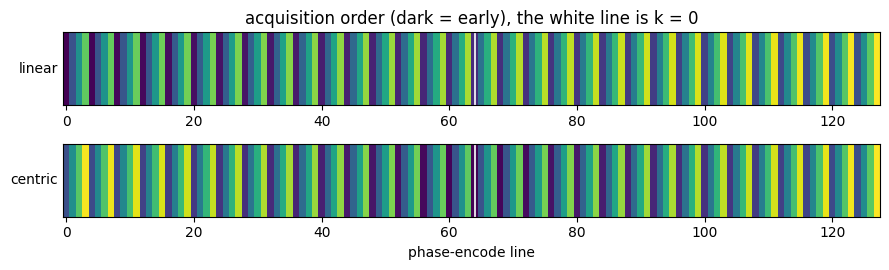

In [10]:
fig, axes = plt.subplots(len(segmentations), 1, figsize=(9, 2.8))
for ax, (name, segments) in zip(axes, segmentations.items()):
    order = np.zeros(NY)
    for index, line in enumerate(line for segment in segments for line in segment):
        order[line] = index
    ax.imshow(order[None, :], aspect='auto', cmap='viridis',
              extent=(-0.5, NY - 0.5, 0, 1))
    ax.axvline(CENTER_LINE, color='w', lw=1.2)
    ax.set(yticks=[], ylabel=name, xlabel='')
    ax.set_ylabel(name, rotation=0, ha='right', va='center')
axes[-1].set_xlabel('phase-encode line')
axes[0].set_title('acquisition order (dark = early), the white line is k = 0')
fig.tight_layout()

---
# 5. The shot loop

One shot per segment, `SHOT_INTERVAL_S` apart. `DUMMY_SHOTS` whole shots come first — inversion,
train and recovery, with the train's `acquire=False`.

**Whole shots, not TRs.** MPRAGE's steady state is a shot-to-shot equilibrium of the
*longitudinal* recovery, so `GRE2D`'s per-TR `dummies` is the wrong knob and stays at `0`. What
has to reach equilibrium is how much magnetisation is left when the next inversion arrives, and
only a whole shot moves that.

**`DUMMY_SHOTS = 5`, and that number is measured rather than chosen.** Interleaved segmentation
gives each shot a *comb* in k-space — shot 0 owns every fourth line — so a difference in signal
between shots is not a smooth shading across k-space but a **periodic modulation**, and a
periodic modulation of k-space is a replica of the object at FOV/4.

Simulating this scan at several dummy-shot counts gives the mean signal spread across shots:
**296 % with none, 48 % with one, 8.7 % with three**, and the replica is plainly visible in the
reconstruction for the first two. Five is where it stops changing. Nothing about the gradient
spoiling affects it — turning the extra spoiler axes off moves the image background by 0.01 % —
so this is the knob, and it is the one MPRAGE has for a shot-to-shot equilibrium.

One warning is deliberately suppressed. `GRE2D` warns when a table omits `center_line`, because
an image with no DC term reads as a windowing problem — but under segmentation that is true of
every shot except one, and the composite has already checked the stronger statement: `k = 0`
appears in exactly one segment. A warning that is right for one consumer and wrong for another is
answered by the consumer that knows more.

In [11]:
import warnings


def scan(segments, *, dummy_shots=DUMMY_SHOTS):
    """Stack one shot per segment, after `dummy_shots` unacquired ones."""
    interval = float(block_raster.ceil(SHOT_INTERVAL_S))
    # Every shot inherits the geometry of the one that carries k = 0, so that each line lands at
    # the same point on the recovery curve *within its own train*.  That uniformity is what makes
    # the contrast continuous across k-space; only one shot's TI is physically meaningful.
    reference = next(segment for segment in segments if CENTER_LINE in segment)
    offset = train_offset_s(reference)

    out = sc.LogicBlock('scan')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        for index in range(-dummy_shots, len(segments)):
            acquire = index >= 0
            segment = segments[max(index, 0)]
            t_shot = (index + dummy_shots) * interval
            if acquire:
                out.add(t_shot, pp.make_label(type='SET', label='TRID', value=1))
            out.add(t_shot, inv())
            out.add(t_shot + offset, train(segment, acquire=acquire))
    return out


raw = scan(segmentations['centric'])
raw_seq = sc.compile(raw, opts, name='mprage_2d_centric')

print(f'{len(raw)} nodes, {len(raw_seq.block_events)} pulseq blocks, '
      f'{raw_seq.duration()[0]:.3f} s')

22 nodes, 1187 pulseq blocks, 21.048 s


C:\Users\bughh\AppData\Local\Temp\ipykernel_37216\3597315148.py:28: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 798.790 ms), scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 798.790 ms), scan.GRE2D.GRE2DTR.PhaseEncode, scan.GRE2D.GRE2DTR.spoiler (grad 141% at 801.890 ms), scan.GRE2D.GRE2DTR.PhaseEncode, scan.GRE2D.GRE2DTR.spoiler (slew 139% at 801.890 ms), scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 806.680 ms) (+1147 more sites)
  raw_seq = sc.compile(raw, opts, name='mprage_2d_centric')


> The compile warns that some blocks exceed the **vector-norm** gradient limit. That is expected
> and is not a violation, and it is the same warning `gre_2d/` produces: a phase-encode blip on
> `y` beside a prephaser on `x` reaches √2 of the per-axis slew in vector magnitude while every
> amplifier axis stays inside its own limit.

### Four checks on the loop

In [12]:
labels = raw_seq.evaluate_labels(evolution='adc')
acquired = [line for segment in segmentations['centric'] for line in segment]

# 1. the lines in the file are the lines the segmentation asked for, in acquisition order
seen = [int(v) for v in np.atleast_1d(np.asarray(labels['LIN']))]
assert seen == acquired, 'the LIN labels do not match the segmentation'

# 2. the dummy shot played and sampled nothing
adcs = [e for _, e, _ in sc.flatten(raw) if getattr(e, 'type', '') == 'adc']
rfs = [e for _, e, _ in sc.flatten(raw) if getattr(e, 'type', '') == 'rf']
assert len(adcs) == NY
assert len(rfs) == (N_SHOTS + DUMMY_SHOTS) * (TURBO + 1), 'one inversion + TURBO excitations/shot'

# 3. a dummy shot is exactly as long as an acquired one -- it is a shot, not a delay
dummy = scan(segmentations['centric'], dummy_shots=1)
none = scan(segmentations['centric'], dummy_shots=0)
assert abs((dummy.duration - none.duration) - block_raster.ceil(SHOT_INTERVAL_S)) < 1e-9

# 4. TI is what it says, measured through the whole scan rather than through one shot
k = sc.kspace(raw, opts)
t_echo = float(k['t_adc'].reshape(NY, NX)[acquired.index(CENTER_LINE), NX // 2])
shot_of_centre = acquired.index(CENTER_LINE) // TURBO
t_inversion = ((shot_of_centre + DUMMY_SHOTS) * float(block_raster.ceil(SHOT_INTERVAL_S))
               + inv.time_to_center())
assert abs((t_echo - t_inversion) - TI_S) < 1e-5

print(f'lines acquired      {len(seen)}, in the order the segmentation gives')
print(f'RF events           {len(rfs)}  ({N_SHOTS + DUMMY_SHOTS} inversions, '
      f'{(N_SHOTS + DUMMY_SHOTS) * TURBO} excitations)')
print(f'readouts            {len(adcs)}  (the dummy shot sampled none of them)')
print(f'a dummy shot costs  {(dummy.duration - none.duration) * 1e3:.1f} ms  '
      f'= one shot interval')
print(f'TI through the scan {(t_echo - t_inversion) * 1e3:.4f} ms')

lines acquired      128, in the order the segmentation gives
RF events           297  (9 inversions, 288 excitations)
readouts            128  (the dummy shot sampled none of them)
a dummy shot costs  2500.0 ms  = one shot interval
TI through the scan 800.0077 ms


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 798.790 ms), scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 798.790 ms), scan.GRE2D.GRE2DTR.PhaseEncode, scan.GRE2D.GRE2DTR.spoiler (grad 141% at 801.890 ms), scan.GRE2D.GRE2DTR.PhaseEncode, scan.GRE2D.GRE2DTR.spoiler (slew 139% at 801.890 ms), scan.GRE2D.GRE2DTR.CartesianLine, scan.GRE2D.GRE2DTR.Excitation, scan.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 806.680 ms) (+1147 more sites)
  seq = compile_sequence(tree, opts)


---
# 6. The same composition, written as a module

The third pass `gre_2d/01_build.ipynb` established: the working loop above, turned into a class.
It is an `sc.Module` subclass even here, because that is what supplies `_finalize`'s type check
and the provenance path — and because the contract is what the notebook is teaching.

**It stays in this notebook.** `MPRAGE2D` has one consumer, and a module with one consumer
belongs where that consumer is. `IRPrep` ships because two notebooks use it; `GRE2D` ships
because `gre_2d/` and this one do. Promote this class the day a 3D variant or a study script
needs it, and not before.

What it adds over the loop is the **refusals**: the two minima, and four things about `segments`
that the compiler cannot see.

In [13]:
class MPRAGE2D(sc.Module):
    """Inversion, wait, GRE train, recover -- once per segment."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, ti_s, shot_interval_s,
                 flip_deg=8.0, te_s=None, tr_s=None, bandwidth_hz_px=200.0,
                 inversion_thickness_mm=None, inversion_pulse='hypsec',
                 inversion_duration_s=10e-3, inversion_spoil_cycles_per_voxel=8.0,
                 dummy_shots=0, rf_spoil=True, rf_spoil_deg=None,
                 spoil_cycles_per_voxel=4.0, tag=None):
        super().__init__(opts=opts, tag=tag)
        self.ti_s = float(ti_s)
        self.shot_interval_s = float(shot_interval_s)
        self.dummy_shots = int(dummy_shots)
        # The two submodules, held as plain attributes: composition needs no API.  The inversion
        # crusher winds its cycles across the slice, which is the voxel dimension along z.
        self.inversion = sc.modules.IRPrep(
            opts=opts, thickness_mm=inversion_thickness_mm, pulse=inversion_pulse,
            duration_s=inversion_duration_s, spoil_voxel_mm=thickness_mm,
            spoil_cycles_per_voxel=inversion_spoil_cycles_per_voxel,
        )
        self.gre = sc.modules.GRE2D(
            opts=opts, fov_mm=fov_mm, matrix=matrix, thickness_mm=thickness_mm,
            flip_deg=flip_deg, te_s=te_s, tr_s=tr_s, bandwidth_hz_px=bandwidth_hz_px,
            rf_spoil=rf_spoil, rf_spoil_deg=rf_spoil_deg,
            spoil_cycles_per_voxel=spoil_cycles_per_voxel,
        )
        self._prep_s = self.inversion().duration
        self._raster = sc.Raster(opts.grad_raster_time)
        self._block_raster = sc.Raster(opts.block_duration_raster)

    # --------------------------------------------------------------- what it knows
    @property
    def center_line(self):
        return self.gre.center_line

    # The public pair validates and the private pair does not, so that one ``build`` runs
    # ``_check`` exactly once.  Checking three times is not slow, but it warns three times, and a
    # warning repeated is a warning ignored.
    def min_ti_s(self, *, segments):
        """The shortest TI that keeps the train clear of the inversion block."""
        return self._min_ti_s(self._check(segments))

    def min_shot_interval_s(self, *, segments):
        """The shortest inversion-to-inversion interval: the train has to finish inside it."""
        return self._min_shot_interval_s(self._check(segments))

    def _min_ti_s(self, table):
        return (self._prep_s - self.inversion.time_to_center() + self._in_train_s(table))

    def _min_shot_interval_s(self, table):
        return (self._train_offset_s(table)
                + max(len(segment) for segment in table) * self.gre.tr.tr_s)

    # ------------------------------------------------------------------- assembly
    def build(self, *, segments, center_mm=(0.0, 0.0, 0.0)):
        table = self._check(segments)
        self._refuse_short(table)
        offset = self._train_offset_s(table)
        interval = float(self._block_raster.ceil(self.shot_interval_s))

        out = sc.LogicBlock()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            for index in range(-self.dummy_shots, len(table)):
                acquire = index >= 0
                t_shot = (index + self.dummy_shots) * interval
                if acquire:
                    out.add(t_shot, pp.make_label(type='SET', label='TRID', value=1))
                out.add(t_shot, self.inversion())
                out.add(t_shot + offset,
                        self._train(table[max(index, 0)], acquire=acquire, center_mm=center_mm))
        return out

    def _train(self, segment, *, acquire, center_mm):
        """One turbo train.  `dummies=0`: MPRAGE's steady state is shot-to-shot."""
        if acquire:
            return self.gre(lines=segment, dummies=0, center_mm=center_mm)
        out = sc.LogicBlock('GRE2D')
        for n, line in enumerate(segment):
            out.add(n * self.gre.tr.tr_s,
                    self.gre.tr(line=line, phase_deg=self.gre.phase_deg(n), acquire=False,
                                center_mm=center_mm))
        return out

    # --------------------------------------------------------------------- timing
    def _in_train_s(self, table):
        """
        Seconds from the start of a train to the readout TI is referenced to.

        The segment carrying k = 0 defines it, and every shot inherits that geometry.  With no
        such segment there is no k = 0 to reference -- ``_check`` has already warned -- and TI
        falls back to the first acquired echo, which is stated rather than silent.
        """
        reference = next((s for s in table if self.center_line in s), None)
        if reference is None:
            return self.gre.tr.time_to_echo()
        return self.gre.time_to_center_line(lines=reference)

    def _train_offset_s(self, table):
        return float(self._raster.ceil(
            self.inversion.time_to_center() + self.ti_s - self._in_train_s(table)
        ))

    # ----------------------------------------------------------------- the refusals
    def _refuse_short(self, table):
        floor = self._min_ti_s(table)
        if self.ti_s < floor - 1e-12:
            tail = self._prep_s - self.inversion.time_to_center()
            in_train = self._in_train_s(table)
            dominant = 'the prep tail' if tail > in_train else 'the position of k = 0 in the train'
            raise sc.ConfigurationError(
                f'ti_s = {self.ti_s * 1e3:.3f} ms is below the minimum {floor * 1e3:.3f} ms, '
                f'and {dominant} dominates it ({tail * 1e3:.3f} ms prep tail + '
                f'{in_train * 1e3:.3f} ms in-train).  Below it the first excitation overlaps the '
                f'inversion crusher, which the compiler sums rather than rejects.'
            )
        floor = self._min_shot_interval_s(table)
        if self.shot_interval_s < floor - 1e-12:
            raise sc.ConfigurationError(
                f'shot_interval_s = {self.shot_interval_s * 1e3:.3f} ms is below the minimum '
                f'{floor * 1e3:.3f} ms, so the train would run into the next inversion.'
            )

    def _check(self, segments):
        """
        Four things about the segmentation the compiler cannot see.

        A fifth was written and then deleted: *"the centre line must not appear in more than one
        segment"* is not a separate rule, because a line in two segments **is** a duplicate line
        and the overlap check above already refuses it.  Two checks for one condition is one
        message that never fires, which is worse than no check at all.
        """
        table = tuple(tuple(int(line) for line in segment) for segment in segments)
        if not table or not all(table):
            raise sc.ConfigurationError('segments must be a non-empty list of non-empty shots')

        seen = [line for segment in table for line in segment]
        ny = self.gre.tr.matrix[1]
        out_of_range = sorted({line for line in seen if not 0 <= line < ny})
        if out_of_range:
            raise sc.ConfigurationError(
                f'{len(out_of_range)} line(s) fall outside 0 ... {ny - 1}: {out_of_range[:8]}.'
            )

        repeated = sorted({line for line in seen if seen.count(line) > 1})
        if repeated:
            raise sc.ConfigurationError(
                f'{len(repeated)} line(s) appear in more than one segment: {repeated[:8]}.  '
                f'Two shots writing one k-space address is what the compiler rejects downstream, '
                f'with less to say about it than here.'
            )

        carrying = [i for i, segment in enumerate(table) if self.center_line in segment]
        if not carrying:
            warnings.warn(
                f'no segment contains the centre line {self.center_line}, so the image has no DC '
                f'term and there is no k = 0 for TI to reference; it falls back to the first '
                f'acquired echo of the first shot.',
                sc.SeqCraftWarning, stacklevel=3,
            )
        if len({len(segment) for segment in table}) > 1:
            warnings.warn(
                'segments are of unequal length, so the shot carrying k = 0 sits at a different '
                'point on the recovery curve from its neighbours -- a contrast discontinuity '
                'across k-space rather than a bug the compiler can see.',
                sc.SeqCraftWarning, stacklevel=3,
            )
        return table


mprage = MPRAGE2D(
    opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
    ti_s=TI_S, shot_interval_s=SHOT_INTERVAL_S, flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, spoil_cycles_per_voxel=SPOIL_CYCLES,
    inversion_pulse=INVERSION_PULSE, inversion_duration_s=INVERSION_DURATION_S,
    inversion_spoil_cycles_per_voxel=INVERSION_SPOIL_CYCLES, dummy_shots=DUMMY_SHOTS,
)

print(mprage(segments=segmentations['centric']))
print(f'min TI            {mprage.min_ti_s(segments=segmentations["centric"]) * 1e3:8.3f} ms')
print(f'min shot interval {mprage.min_shot_interval_s(segments=segmentations["centric"]) * 1e3:8.3f} ms')

LogicBlock(MPRAGE2D, 22 nodes, 21048.12 ms)
min TI               6.708 ms
min shot interval 1048.120 ms


### The class is the loop, and nothing else

In [14]:
def event_digest(tree):
    """Every leaf event as (absolute time, content hash), tags and nesting ignored."""
    return sorted((round(t, 12), sc.events.content_hash(e)) for t, e, _ in sc.flatten(tree))


for name, segments in segmentations.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        assert event_digest(scan(segments)) == event_digest(mprage(segments=segments))
    print(f'{name:8s} the class and the loop are the same events, at the same instants')

paths = sorted({path for _, _, path in sc.flatten(mprage(segments=segmentations['centric']))})
print()
for path in paths:
    print('  ' + ' -> '.join(path))

linear   the class and the loop are the same events, at the same instants


centric  the class and the loop are the same events, at the same instants

  MPRAGE2D
  MPRAGE2D -> GRE2D -> GRE2DTR
  MPRAGE2D -> GRE2D -> GRE2DTR -> CartesianLine
  MPRAGE2D -> GRE2D -> GRE2DTR -> Excitation
  MPRAGE2D -> GRE2D -> GRE2DTR -> PhaseEncode
  MPRAGE2D -> GRE2D -> GRE2DTR -> spoiler
  MPRAGE2D -> IRPrep
  MPRAGE2D -> IRPrep -> spoiler


Four levels deep — `MPRAGE2D → GRE2D → GRE2DTR → CartesianLine` — and not one tag string was
written by hand. That is the deepest nesting the package has produced, and it is still legible
in a compiler warning, which was the open question this sequence was meant to answer.

### The refusals, each shown once

In [15]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what:24s} {str(error).splitlines()[0][:96]}')
    else:
        raise AssertionError(f'{what} was not refused')


too_short = MPRAGE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     ti_s=5e-3, shot_interval_s=SHOT_INTERVAL_S, flip_deg=FLIP_DEG,
                     bandwidth_hz_px=BANDWIDTH_HZ_PX, inversion_pulse=INVERSION_PULSE,
                     inversion_duration_s=INVERSION_DURATION_S)
crowded = MPRAGE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                   ti_s=TI_S, shot_interval_s=0.2, flip_deg=FLIP_DEG,
                   bandwidth_hz_px=BANDWIDTH_HZ_PX, inversion_pulse=INVERSION_PULSE,
                   inversion_duration_s=INVERSION_DURATION_S)

refused('TI below the floor', lambda: too_short(segments=segmentations['centric']))
refused('shot interval too short', lambda: crowded(segments=segmentations['centric']))
# One line in two shots is also how "the centre line in two segments" arrives, which is why that
# is not a check of its own.
refused('a line in two segments', lambda: mprage(segments=[(0, 32), (32, 1)]))
refused('a line out of range', lambda: mprage(segments=[(0, 32), (1, NY)]))
refused('an empty segmentation', lambda: mprage(segments=[]))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    mprage(segments=[(0, 1, 2), (3, 4, 5)])                       # no centre line
    mprage(segments=[tuple(range(0, 33)), tuple(range(33, NY))])  # unequal lengths
print()
for warning in caught:
    print(f'warned: {str(warning.message).splitlines()[0][:96]}')

TI below the floor       ti_s = 5.000 ms is below the minimum 6.708 ms, and the position of k = 0 in the train dominates 
shot interval too short  shot_interval_s = 200.000 ms is below the minimum 1048.120 ms, so the train would run into the n
a line in two segments   1 line(s) appear in more than one segment: [32].  Two shots writing one k-space address is what 
a line out of range      1 line(s) fall outside 0 ... 127: [128].
an empty segmentation    segments must be a non-empty list of non-empty shots

warned: no segment contains the centre line 64, so the image has no DC term and there is no k = 0 for TI
warned: segments are of unequal length, so the shot carrying k = 0 sits at a different point on the reco


---
# 7. The TI sweep

The same segmentation at several inversion times. What moves is where the train sits inside the
shot — the train itself is unchanged, and `time_to_center_line` is what keeps `k = 0` pinned to
the requested TI while it moves. `02` turns this into a recovery curve.

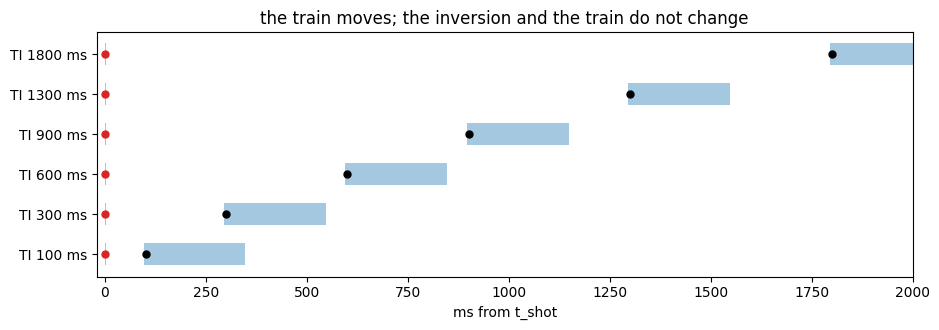

In [16]:
TI_SWEEP = (0.10, 0.30, 0.60, 0.90, 1.30, 1.80)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
for row, ti in enumerate(TI_SWEEP):
    swept = MPRAGE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     ti_s=ti, shot_interval_s=SHOT_INTERVAL_S, flip_deg=FLIP_DEG,
                     bandwidth_hz_px=BANDWIDTH_HZ_PX, inversion_pulse=INVERSION_PULSE,
                     inversion_duration_s=INVERSION_DURATION_S)
    reference = segmentations['centric'][0]
    offset = swept._train_offset_s(swept._check(segmentations['centric']))
    train_s = TURBO * gre.tr.tr_s
    ax.barh(row, prep_s * 1e3, left=0, height=0.55, color='C3', alpha=0.4)
    ax.barh(row, train_s * 1e3, left=offset * 1e3, height=0.55, color='C0', alpha=0.4)
    t_k0 = (offset + gre.time_to_center_line(
        lines=next(s for s in segmentations['centric'] if CENTER_LINE in s))) * 1e3
    ax.plot([t_k0], [row], 'ko', ms=5)
    ax.plot([inv.time_to_center() * 1e3], [row], 'o', color='C3', ms=5)

ax.set(yticks=range(len(TI_SWEEP)),
       yticklabels=[f'TI {ti * 1e3:.0f} ms' for ti in TI_SWEEP],
       xlabel='ms from t_shot', title='the train moves; the inversion and the train do not change')
ax.set_xlim(-20, (TI_SWEEP[-1] + 0.2) * 1e3)
fig.tight_layout()

---
## The two files

One instance, two segmentations, two cheap calls. `02` reads the `LIN` labels back out of these
files rather than assuming acquisition order — under segmentation the two are no longer the same,
which is exactly what the label was for.

In [17]:
nominal = {}
for name, segments in segmentations.items():
    tree = mprage(segments=segments)
    seq = sc.compile(tree, opts, name=f'mprage_2d_{name}', definitions={
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'kSpaceCenterLine': CENTER_LINE,
        'TE': gre.tr.te_s,
        'TR': gre.tr.tr_s,
        'TI': TI_S,
        'FlipAngle': FLIP_DEG,
        'ReceiverBandwidth': BANDWIDTH_HZ_PX,
    })
    seq.write(str(SEQ_DIR / f'mprage_2d_{name}.seq'))
    acquired = [line for segment in segments for line in segment]
    nominal[name] = sc.kspace(tree, opts)['k_adc'].reshape(3, len(acquired), NX)
    print(f'{name:8s} {len(seq.block_events):5d} blocks   {seq.duration()[0]:6.2f} s   '
          f'-> seq/mprage_2d_{name}.seq')

np.savez(
    SEQ_DIR / 'mprage_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, turbo=TURBO, dummy_shots=DUMMY_SHOTS,
    ti_s=TI_S, shot_interval_s=SHOT_INTERVAL_S, te_s=gre.tr.te_s, tr_s=gre.tr.tr_s,
    flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX,
    inversion_pulse=INVERSION_PULSE, inversion_duration_s=INVERSION_DURATION_S,
    inversion_time_to_center_s=inv.time_to_center(),
    **{f'segments_{name}': np.array(segments) for name, segments in segmentations.items()},
    **{f'k_{name}': k for name, k in nominal.items()},
)
print(f'-> {SEQ_DIR / "mprage_2d_nominal.npz"}')

C:\Users\bughh\AppData\Local\Temp\ipykernel_37216\1375456544.py:4: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 110% at 672.550 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 165% at 672.550 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (grad 148% at 675.650 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (slew 169% at 675.650 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 109% at 680.440 ms) (+1147 more sites)
  seq = sc.compile(tree, opts, name=f'mprage_2d_{name}', definitions={


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 110% at 672.550 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 165% at 672.550 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (grad 148% at 675.650 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (slew 169% at 675.650 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 109% at 680.440 ms) (+1147 more sites)
  seq = compile_sequence(tree, opts)


linear    1187 blocks    20.92 s   -> seq/mprage_2d_linear.seq


C:\Users\bughh\AppData\Local\Temp\ipykernel_37216\1375456544.py:4: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 798.790 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 798.790 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (grad 141% at 801.890 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (slew 139% at 801.890 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 806.680 ms) (+1147 more sites)
  seq = sc.compile(tree, opts, name=f'mprage_2d_{name}', definitions={


centric   1187 blocks    21.05 s   -> seq/mprage_2d_centric.seq
-> seq\mprage_2d_nominal.npz


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 1152 blocks over the vector-norm limit (legal on real amplifiers): MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 798.790 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 798.790 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (grad 141% at 801.890 ms), MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode, MPRAGE2D.GRE2D.GRE2DTR.spoiler (slew 139% at 801.890 ms), MPRAGE2D.GRE2D.GRE2DTR.CartesianLine, MPRAGE2D.GRE2D.GRE2DTR.Excitation, MPRAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 806.680 ms) (+1147 more sites)
  seq = compile_sequence(tree, opts)


---
## What this notebook established

| | |
|---|---|
| TI is measured from the inversion's **effective centre** | `time_to_center()`, and referencing the block start instead is a 5 ms error for a 10 ms hyperbolic secant |
| k = 0 sits **somewhere inside** the train, and where depends on the ordering | `time_to_center_line(lines=…)`, which is why it takes the same arguments `build` does |
| the `dummies` term in that query is **not optional** | the block starts at the first dummy; dropping it under-reports by `dummies · TR`, silently |
| `min_ti_s` is a **prep tail plus an in-train offset** | and each dominates in a different regime: centric is floored by the tail, linear by half a train |
| too short a TI **overlaps rather than fails** | `LogicBlock` permits overlap, the compiler sums on `z`, and the sequence is wrong rather than rejected |
| dummy shots are **whole shots** | the steady state is a shot-to-shot equilibrium of the longitudinal recovery, so per-TR dummies are the wrong knob |
| every shot **inherits the geometry** of the one carrying k = 0 | only one shot's TI is meaningful; the rest exist to put every line at the same point of its own train |

`IRPrep` is the only piece of this that ships. `MPRAGE2D` has one consumer — this notebook — and
stays here until a second one appears.

Next: [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) asks whether the
magnetisation does what this timeline says, starting with the question everything else depends
on: does the simulator invert at all?